<a href="https://colab.research.google.com/github/mauracarter-statistics/csc162/blob/main/carter_maura_162_mod3_coffeecup_canny_edge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Maura Carter**; CSC 162 Fall 2025; November 27, 2025.

**INSTRUCTIONS**

**Overview**
In this assignment, you will demonstrate your understanding of key computer vision techniques by creating a hands-on Google Colab Notebook using a free online image (a coffee cup image). You will:

1. Detect Edges: Identify boundaries and highlight changes in image intensity using OpenCV’s Canny algorithm.

2. Plot Histograms: Visualize the distribution of pixel intensities to analyze contrast and guide preprocessing decisions.

3. Extract Feature Maps: Build a simple Convolutional Neural Network (CNN) with TensorFlow/Keras to extract and visualize feature maps that represent learned image features.

Follow the tasks below and use the suggested starter snippets as a guide.

*If needed, review the following lecture:

*Video - Edge Detection, Histograms, and Feature Maps in Computer Vision Lecture: https://www.youtube.com/watch?v=g8CB27s7VIQ


**ASSIGNMENT TASKS**


**TASK 1: Import Libraries and Load the Image**

**Objective:** Import required libraries and download the provided coffee cup image.

**Instructions:**

1. Import the following libraries: OpenCV (cv2), NumPy, urllib.request, and matplotlib.pyplot.

2. Use the provided image URL to download the image. # Image URL (coffee cup image from Wikimedia Commons) image_url = 'https://upload.wikimedia.org/wikipedia/commons/4/45/A_small_cup_of_coffee.JPG'

3. Convert the image from OpenCV’s BGR format to RGB.
4. Display the original image using matplotlib.

**Suggested Starter Snippet:**

**Import the libraries needed.** This is including cv2 to change colors of the image, and numpy, as well as matplotlib to display the plot and any other needed imports.

Numpy is a key library in Python for scientific computing. It has a lot of efficienty and ability to do processing of arrays, which makes numpy extremely importatn for tasks that involve high amount of data, large datasets, and complex numerical calculations or tasks. Mahy computer vision tasks require calculations and use of a large volume of data (such as many, many pixels in an image for image data, or multiple images).

In [1]:
#python
# Starter snippet for Task 1: Import Libraries and Load the Image
import cv2      #cv2 is used for many computer vision tasks such as the functions within it that allow changing color schemes or using the Canny edge detector function.
import numpy as np
import urllib.request   #'request' from the package urllib allows us to access a URL link to the free image, or deal with HTTP actions.
import matplotlib.pyplot as plt


**Define the image URL.** (For the coffee cup image).

Use the given URL link to the free image of the coffee cup from wikipedia.

In [2]:

# Image URL (coffee cup image from Wikimedia Commons)
image_url = 'https://upload.wikimedia.org/wikipedia/commons/4/45/A_small_cup_of_coffee.JPG'



**Download the coffee cup image from the URL.**

The 'request' from the urllib package allows you to read URL's, and handle HTTP features. We need this to read the URL link that contains the free coffeecup image.

In [3]:
#Make sure the appropriate libraries/packages are loaded, including numpy.
import urllib.request  #'request' from the urllib package allows you to read URL's, and handle HTTP features. We need this to read the URL link that contains the free coffeecup image.
import numpy as np


# TODO: Download the image from the URL

# - urllib.request.urlopen - this retrieves the image data.
# - bytearray and np.asarray converts the retrieved data into a NumPy array. Python deals with arrays.
req = urllib.request.Request(image_url, headers={'User-Agent': 'Mozilla/5.0'})
resp = urllib.request.urlopen(req)
image_data = np.asarray(bytearray(resp.read()), dtype="uint8")

**Decode the coffee cup image.** Read the image in color.

In [4]:
# TODO: Decode the image using cv2.imdecode (make sure to use cv2.IMREAD_COLOR)

# Decode the image data using OpenCV's imdecode method.
# - cv2 contains functions that direct or change the color scheme of the image. cv2.IMREAD_COLOR function makes sure that the image is read in color.
image = cv2.imdecode(image_data, cv2.IMREAD_COLOR)



**Convert the coffee cup image color.** (From default blue-green-red to red-green-blue).

In [5]:
# TODO: Convert the image from BGR to RGB
# OpenCV loads images in BGR (blue-green-red) format by default. We want to change it to red-green-blue (RGB) format. Use the cv2.COLOR_BGR2RGB function to convert the color order.
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


**Display the coffee cup image.** Add a title to the image.

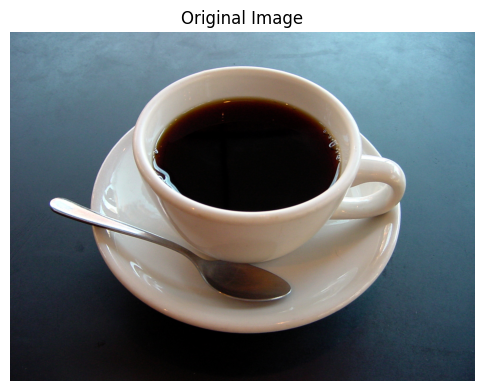

In [6]:
# TODO: Display the original image with matplotlib

plt.figure(figsize=(6,6))   #specify the parameters for the size of the image.
plt.imshow(image_rgb) #this function plt.imshow() displays that image that is denoted (here, it denotes the image image_rbg) which is the red-green-blue image from the code chunk above.
plt.title('Original Image') #the function plt.title adds a title to the displayed image, above the image. Specify the title in single quotes.
plt.axis('off') #turn off the axis lines
plt.show()   #this function shows the image in addition all the items that have been added to it (such as title, axis (or no axis), etc.)

**TASK 2: Edge Detection Using the Canny Algorithm**

**Objective:** Convert the image to grayscale and apply edge detection to highlight boundaries.

**Instructions:**

1. Convert the loaded image to grayscale.

2. Apply the Canny algorithm with appropriate threshold values.

3. Display the edge-detected output.

**Suggested Starter Snippet:**

**Convert the coffee cup image to Greyscale** (use cv2.cvtColor).

The defalut color scheme is BGR the default when importing images into OpenCV on Google Collab, and we use the cv2.cvtColor (specifically, the function cv2.COLOR_BGR2GRAY) to convert the blue-green-red default colors to grayscale color scheme. This will later be the color scheme (gray) image used for the Canny edge-detection.

In [7]:
#python
# Starter snippet for Task 2.
# TODO: Convert the image to grayscale using cv2.cvtColor (specifically, the cv2.COLOR_BGR2GRAY function)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)



**Apply the Canny edge detector** to the coffee cup image.

Use the cv2.Canny to do the Canny edge detector and define the parameters including which image to use and the threshold values.

In [8]:
# TODO: Apply the Canny edge detector (use threshold values 100 and 200)

# - The parameters threshold1 and threshold2 (100 and 200) control the sensitivity.
# - Lower thresholds capture more edges but may include noise; higher thresholds provide cleaner edges.
edges = cv2.Canny(gray, threshold1=100, threshold2=200)   #cv2.Canny is the canny edge-detector and it has several parameters, including the name of the image (in this case, the grayscale coffee cup image from the above code chunk) and we used the pre-defined threshold values of 100 and 200 for the threshold paraemters.


**Display the edge-detected coffee cup image.**

**The Canny edge-detection** in computer vision is an algorithm that has multiple steps and it is used to locate the true edges of the image. It does this by reducing "noise" to find the true edges. The output looks sort of like a sketch that of an object that hasn't been colored in yet with shading or details. It's basically an outline of the object. Some of the steps use filters that we learned about such as the Gaussian to reduce noise, and Sobel operator to find vertical and horizontal gradients to find the intensity gradient. In another step there is a non-maximum suppression, which means the step "thins" the edges by seeing if a pixel is a local maximum and if it's not, changing it to zero (changing it to zero suppresses it). Then there is something called "Hysteresis Thresholding" where the different edges are examined and determined if they are included in the final output. This focuses on threshold values that are maximums or minimums. Pixel gradients that are above the maximum value included and these are strong edges. Non-edges are below the minimum threshold and are not included, and weak edges are between the minimum and maximum values, and are sometimes included in the final output of edges and sometimes not included. They are more likely to be included if they are connected to a strong edge. After all these steps, you should be left with basically the outline of an image (in this case, the coffee mug) and non-edges or some weak edges are not included (suppressed, so they look like just dark background).

**Below**, we can see that the Canny edge-detection for the coffee cup image did a pretty good job. It renders an outline of the coffee cup, the spoon, and the saucer and it looks like a sketch I'd make if I was drawing this cup or outlining the main shapes, before painting in the shading and colors. In this output, we can see a dark background with the edges made in a lighter color (that looks grey).

See screenshot below for the output image from the Canny Edge Detection.

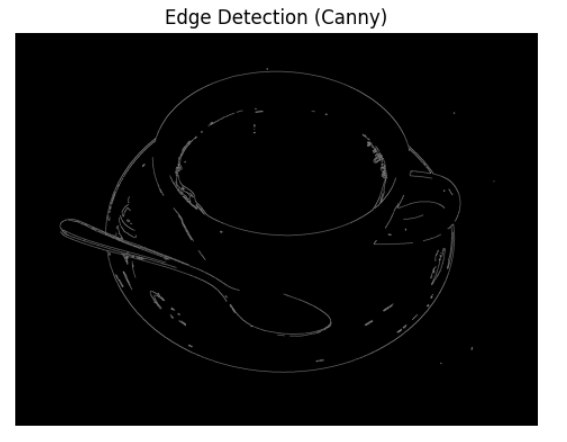

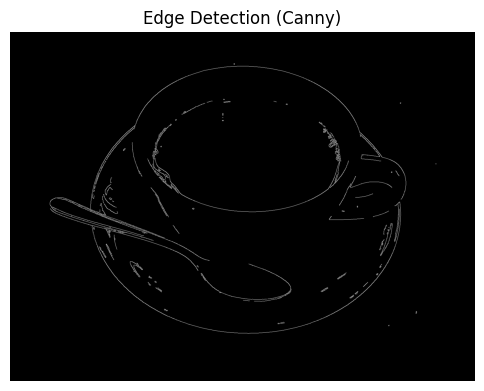

In [9]:
# TODO: Display the edge-detected image
plt.figure(figsize=(6,6))   #defines the size of the output figure
plt.imshow(edges, cmap='gray')  #plt.imshow is a function that displays the image, and here we said the edges from the Canny-edge detection are in gray.
plt.title('Edge Detection (Canny)')  #the function plt.title adds a title to an output image or graph
plt.axis('off')  #plt.axis = 'off' is a function that turns off the display of the axis on the output image (and if we wanted to see it displayed, we would do "on")
plt.show()  #plt.show is a function that displays the image plus any add-ons to the output image including titles, axis labels, etc. In this case, it is showing the add-ons of the gray Canny edge outlines and the image title.

**TASK 3: Plot a Histogram of Pixel Intensities**

**Objective**: Compute and plot a histogram of pixel intensities for the grayscale image.

**Instructions**:

1. Use OpenCV’s calcHist function to compute the histogram.

2. Plot the histogram using matplotlib to show the distribution of pixel intensities from 0 to 255.

**Suggested Starter Snippet:**

**Compute the histogram** that shows the pixel intensities vs the frequency of those pixels.

In [10]:
#python
# Starter snippet for Task 3: Plot a Histogram of Pixel Intensities
# TODO: Compute the histogram using cv2.calcHist
hist = cv2.calcHist([gray], channels=[0], mask=None, histSize=[256], ranges=[0,256])



**Plot the histogram.**

**Histograms show how often a brightness or color level appears** (how many pixels of each, which is the frequency, on the y-axis or vertical axis). The pixel intensity or brightness is shown on the x-axis or the horizontal axis. In this particular grayscale intensities histogram of the coffee cup image, there is a large spike (to just under 50,000) of pixels that are a very low intensity level (slightly above zero, maybe at 10 level of pixel intensity).
There is a drop in the graph where the pixel intensity is around 25 and there are about 10,000 of these pixels. The graph rises again (but not a huge spike) at about 12,000 pixels or 125 intensity. The graph drops to about 2,500 pixels of 250 intensity (very high intensity level but fewer pixels at that level), with a small spike in frequency just after the intensity level of 250 (maybe 252 or 255 intensity level), and this is about 4,500 or 5,000 count of pixels.

See screenshot below for the image of the histogram of grayscale intensities from the coffee cup image.

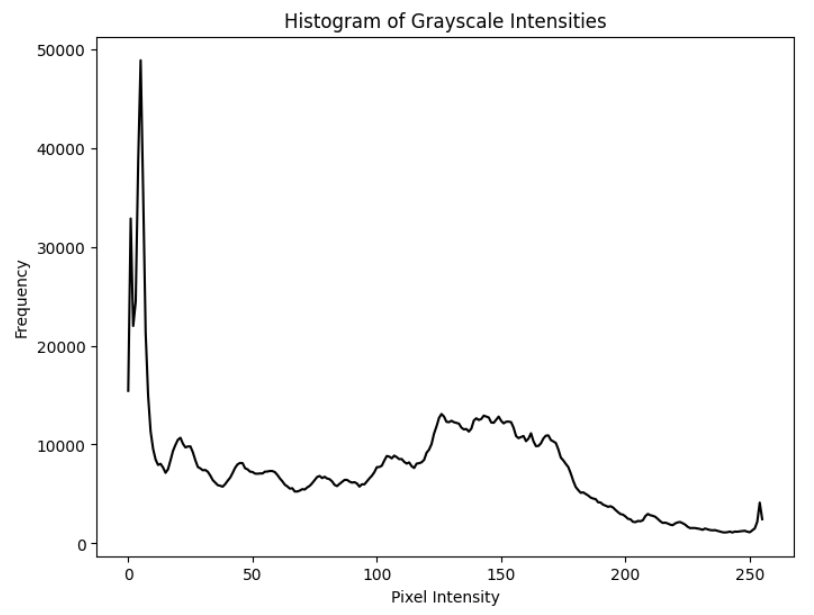

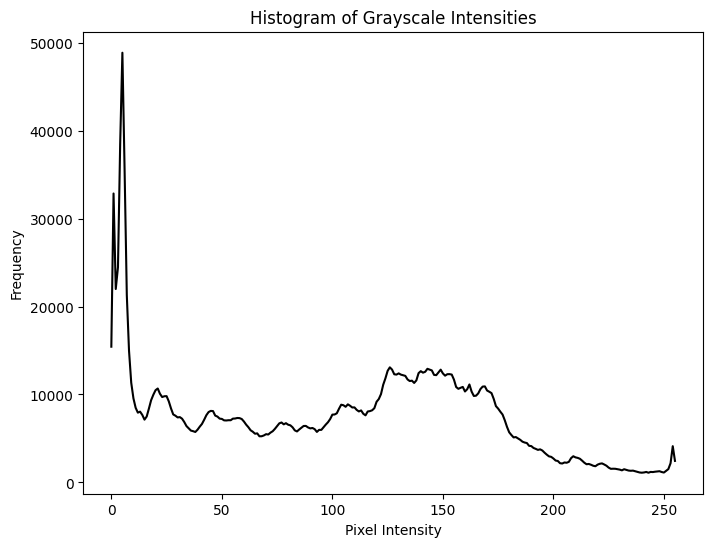

In [11]:
# TODO: Plot the histogram with matplotlib

plt.figure(figsize=(8,6))   #dimensions of the graph/histogram
plt.plot(hist, color='black')   #histogram output is done in black (as opposed to another color or set of colors); black is likely easiest to read.
plt.title("Histogram of Grayscale Intensities")   #plt.title is the function that adds a title to this output/graph
plt.xlabel("Pixel Intensity")  #plt.xlabel adds a label to the x-axis (horizontle axis)
plt.ylabel("Frequency")  #plt.ylabel adds a label to the y-axis (vertical axis)
plt.show()  #displays the graph in addition to any add-ons such as title, axis labels, etc.

**TASK 4: Extract and Visualize Feature Maps Using a Simple CNN**

**Objective**: Build a simple CNN to extract feature maps from the image and visualize them in a grid.

**Instructions:**

1. Preprocess the image for TensorFlow by converting it to float32, normalizing it, and expanding its dimensions.

2. Build a simple CNN model containing one convolutional layer with 8 filters (3×3 kernel, ReLU activation, "same" padding).

3. Run the model to obtain feature maps.

4. Visualize the feature maps in a grid layout.

**Suggested Starter Snippet:**

**Import tensorflow library** and model, input, and conv2D from the keras packages.

TensorFlow is a powerful package that can be used in R or Python that is used in deep learning, creating and training neural networks, and in computer vision.

In [18]:
#python
# Starter snippet for Task 4: Extract and Visualize Feature Maps Using a Simple CNN
import tensorflow as tf     #tensorflow is a powerful package
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D


**Preprocess the image for the CNN.**

This step devides each pixel by the maximum value of 255 and is an important step when making a CNN in order to normalize the image data; it makes it more stable. It makes it so all pixel values (that are input) can be treated with the same importance scale by the network (even if they have different original/raw magnitudes).

In [28]:

# TODO: Preprocess the image for the CNN: normalize and add a batch dimension
input_img = image_rgb.astype('float32') / 255.0    #this step devides each pixel by the maximum value of 255 and is an important step when making a CNN in order to normalize the image data; it makes it more stable. It makes it so all pixel values (that are input) can be treated with the same importance scale by the network (even if they have different original/raw magnitudes)
input_img = np.expand_dims(input_img, axis=0)  # Expected shape: (1, height, width, 3)


**Build a CNN model with 1 convolutional layer.**

In [25]:

# TODO: Build a simple CNN model with one convolutional layer

# - The input layer takes the shape of our preprocessed image.
# - The convolutional layer applies 8 filters with a 3x3 kernel, using ReLU activation.
#we have to define the input layer, the 2D convolutional layer, and the model. the input layer tells the shape and dimensions, the convolutional layer tells how many filters and what size and what kind of activation algorithm to use, and the model tells what parameters to include in the model (in this case, the input with the dimensions, and the convolutional layers with the filters).
# - Padding is set to "same" to ensure that the output feature maps have the same spatial dimensions as the input.
input_layer = Input(shape=input_img.shape[1:])  # Exclude the batch dimension.
conv_layer = Conv2D(filters=8, kernel_size=(3,3), activation='relu', padding='same')(input_layer)  #relu is a common activation algorithm to use; relu is f(x) = max(0, x) which means that positve values stay the same but negative values change to zero. The purpose is to introduce non-linearity and for the network to learn more complex patterns and information. It also creates more efficiency in the model calculations.
model = Model(inputs=input_layer, outputs=conv_layer)  #the model parameters have the input and convolutional layers with 8 filters that we defined above.

**Pass preprocessed image through the CNN to get feature maps.**

In [26]:

# TODO: Pass the preprocessed image through the CNN to obtain the feature maps


# Explanation:
# This simple CNN applies 8 different convolutional filters to the image, thereby generating 8 feature maps.
# These feature maps highlight various aspects, such as edges and textures, learned from the image.

#Different filters look for different features, so not all 8 Feature Maps in the output will look the same.

# Pass the image through the CNN to obtain the feature maps.
feature_maps = model.predict(input_img)
# Remove the batch dimension for visualization. The resulting shape is (height, width, 8).
feature_maps = feature_maps[0]



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step


**Visualize each of the 8 feature maps.**

**NOTE:** *Note about the output feature maps.*

**Solid color maps:** Map 6 and Map 7 appear like a solid color map with no noticable color gradient. Map 5 looks like an almost-solid color with an upper edge to the cup rim showing, so it has a little or subtle gradient. This can happen when its corresponding filter (to the feature map) is not strongly activated by any specific features in the input image. Different filters correspond to different feature maps. The particular filter that corresponded to Map 1 may have been looking for a very particular combination of features that was not present (or that it didn't detect). Perhaps the activation was weak. One of these scenarios also liely happened with the filter that corresponded to Map 5, although this map detected a little more than did the filter that corresponded to Maps 6 & 7, (because I can see the upper rim of the cup in Map 5, and faintly see the bottom rim of the cup).

**Image-like maps:** Feature maps that look like an image show where a filter has detected a pattern. The brighter areas in the map indicate a strong activation of that specific filter, meaning the feature it is designed to detect was found at that location in the input image. Feature Map 2 showed a distinct cup (as did Maps 3, 4, & 8), but Map 2 had the brightest colors including neon yellow/green. There were 4 maps that had most of the coffee cup image in the map - Maps 2, 3, 4, & 8.

**NOTE:** Each time I run the secodn that defines the Input, Conv2D, and Model and then run the neural network and feed in the input image into the model.predict it changes the output (the 8 feature maps look different, each time it's run). When I first ran it, Map 1 was a solid color with no edges, and the next time I ran it, Maps 6 & 7 were solid colors with no edges and Map 1 showed a dark silhouette image of the coffee mug.

Below is a screenshot of the output of the feature maps (all 8) when I **ran the model the second time.**

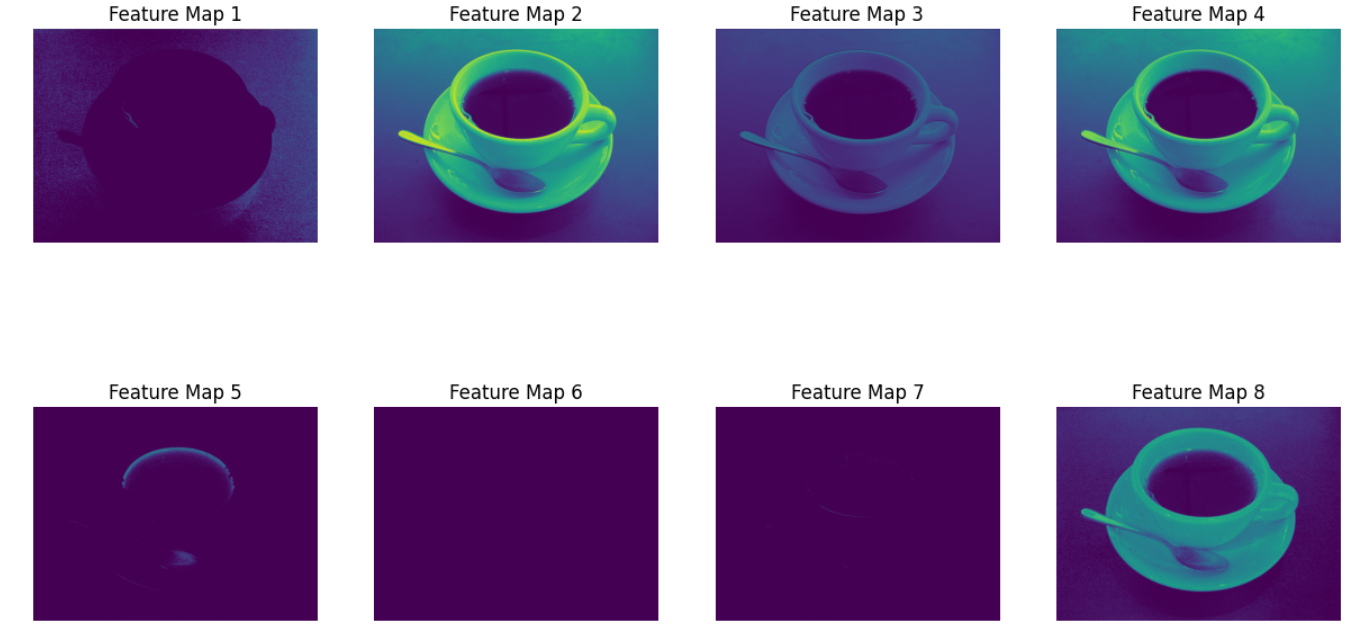

**The third time I ran the model** (see screenshot below), I got more feature maps that had edge outlines instead of the entire image. Maps 2, 4, 6, & 8 were mostly a solid color but had a faint edge outline of the top of the mug, and Maps 2 & 4 had super, super faint edges of the bottom of the mug. There were 3 maps that looked like it had most of the coffee cup image - Maps 1, 3, and 5.

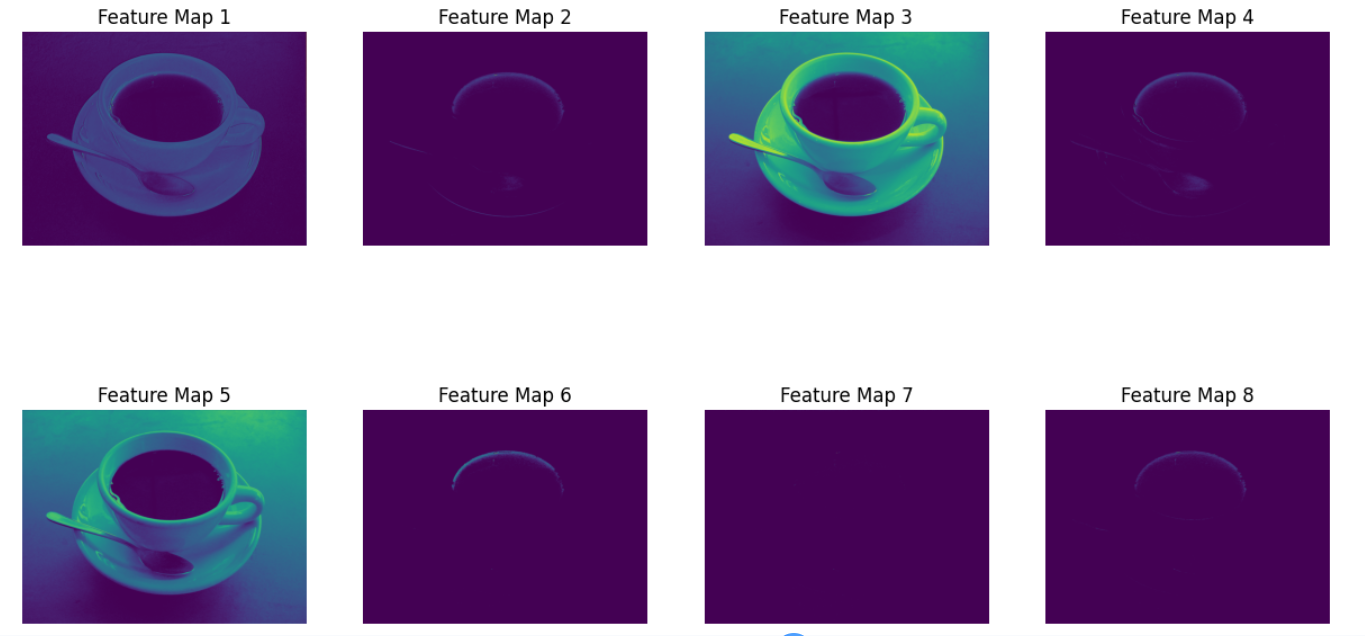

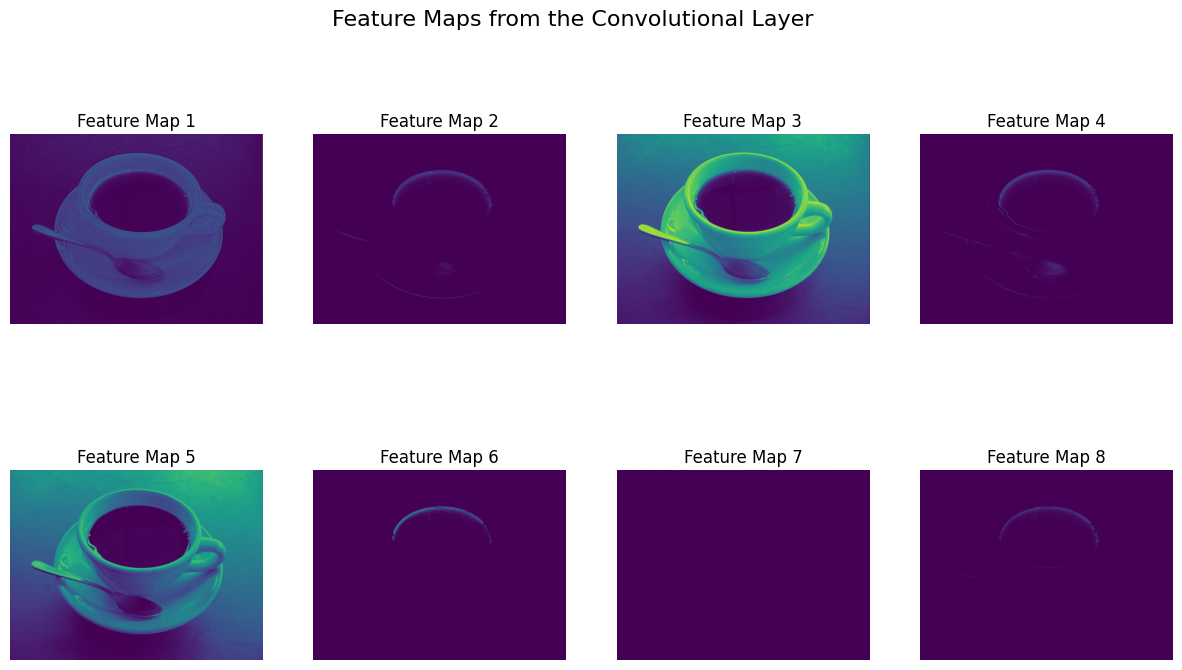

In [27]:

# TODO: Visualize each of the 8 feature maps in a grid (2 rows)

#add Feature Map numbers to each map 1-8.
# - The results are arranged in a grid format with two rows.
num_filters = feature_maps.shape[-1]
plt.figure(figsize=(15,8))   #dimensions of the output size
for i in range(num_filters):
    plt.subplot(2, num_filters // 2, i+1)
    plt.imshow(feature_maps[:,:,i], cmap='viridis')
    plt.title(f'Feature Map {i+1}')   #add a title to the output images called "Feature Map"
    plt.axis('off')   #remove axis lines in the output
plt.suptitle("Feature Maps from the Convolutional Layer", fontsize=16)
plt.show()  #show all 8 feature maps plus any "add ons", such as the title, number labels, etc.

#results: See above comment on why some of the maps look solid color or more blank than others.

**TASK 5. Documentation and Submission**

1. **Documentation**: Ensure that your Colab notebook is well-documented. Include comments in each code cell explaining what each section of code is doing.
2. **File Submission**: When you have completed the assignment, save your Google Colab notebook as a .ipynb file and upload it to Brightspace as your assignment submission. (Example SmithMod03.ipynb)

**NOTE:** Please see the documentation and comments spread throughout the notebook, both in text boxes and as comments inside of code chunks.

**The End. Thank you very much.**